Processing: 20260127_001000_n.mkv
  Start time (from filename): 2026-01-27 00:10:00
  V/div: 2.0, Grid height: 28.417266187050366 px, FPS: 20.0
  Red pixel count threshold: 1000
  Method: 1D vertical profile + threshold-based width calculation
  Frames extracted: 6000
  Vpp range: 1.126 - 1.548 V
  Duration: 299.95 s


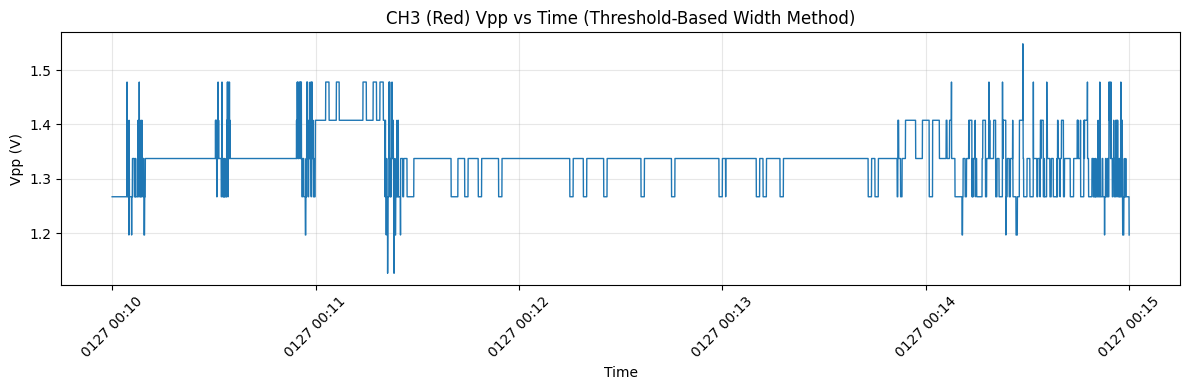

In [3]:
# Cell 1 and 2 are for testing.
# Cell 3: batch process one single date
# Another notebook "_batch" is used for batch processing all dates.

import os
import re
import cv2
import numpy as np
from datetime import datetime, timedelta
from scipy.signal import find_peaks, peak_widths
from scipy.ndimage import gaussian_filter1d

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Parameters (CHANGE)
# test_file = "/Volumes/D06V1/D06V1/OSC_Videos/2026ab/20260224/20260224_205500_n.mkv"
# test_file = "/Volumes/D06V1/D06V1/OSC_Videos/2026ab/20260127/RecData/0014/20260127_001000_n.mkv"
test_file = "/Volumes/D06V1/D06V1/OSC_Videos/2026ab/20260204/RecData/0014/20260204_145000_n.mkv"
peak_threshold = 3.5  # V, for peak detection in Vpp signal
profile_threshold = 1000

# Parameters (DO NOT CHANGE)
grid_height_px = 3.95/5.56*400/10  # for one grid corresponding to 2 V
v_div = 2.0
fps = 20.0

def extract_datetime_from_filename(filename):
    """Extract YYYYMMDD_HHMMSS from filename."""
    match = re.search(r"(\d{8})_(\d{6})", filename)
    if not match:
        return None
    date_part, time_part = match.groups()
    return datetime.strptime(date_part + time_part, "%Y%m%d%H%M%S")


def compute_vpp_series_for_file(file_path, v_div=2.0, fps=20.0, threshold=1000):
    """Compute Vpp for CH3 (red trace) per frame using threshold-based width calculation."""

    cap = cv2.VideoCapture(file_path)
    volts_per_pixel = v_div / grid_height_px

    vpp_series = []
    frame_idx = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        height, width, _ = frame.shape
        roi = frame[int(height * 0.2):int(height * 0.8), int(width * 0.1):int(width * 0.9)]

        hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)

        # CH3: red trace (HSV hue wraps around 0)
        mask1 = cv2.inRange(hsv, np.array([0, 100, 100]), np.array([10, 255, 255]))
        mask2 = cv2.inRange(hsv, np.array([160, 100, 100]), np.array([180, 255, 255]))
        red_mask = cv2.bitwise_or(mask1, mask2)

        # Create 1D vertical profile by summing red pixels along x-axis
        vertical_profile = np.sum(red_mask, axis=1)
        
        # Smooth the profile to handle noise
        smooth_profile = gaussian_filter1d(vertical_profile.astype(float), sigma=2.0)
        
        # Threshold-based width calculation: find y-positions where red pixel count > threshold
        above_threshold = smooth_profile > threshold
        
        if np.any(above_threshold):
            # Find y-positions where red pixel count exceeds threshold
            threshold_positions = np.where(above_threshold)[0]
            
            # Get outermost y-positions (min and max)
            left_bound = threshold_positions[0]
            right_bound = threshold_positions[-1]
            
            # Calculate width in pixels
            peak_width_pixels = right_bound - left_bound
            
            vpp_series.append(peak_width_pixels * volts_per_pixel)
        else:
            vpp_series.append(np.nan)

        frame_idx += 1

    cap.release()

    # Time axis: frame_idx / fps in seconds
    time_series_sec = np.arange(len(vpp_series)) / fps

    return time_series_sec, np.array(vpp_series)


# Extract start time from filename
file_path = test_file
basename = os.path.basename(file_path)
start_dt = extract_datetime_from_filename(basename)

if start_dt is None:
    raise ValueError(f"Could not extract datetime from filename: {basename}")

# v_div = 2.0
# fps = 20.0

print(f"Processing: {basename}")
print(f"  Start time (from filename): {start_dt.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  V/div: {v_div}, Grid height: {grid_height_px} px, FPS: {fps}")
print(f"  Red pixel count threshold: {profile_threshold}")
print(f"  Method: 1D vertical profile + threshold-based width calculation")

time_s, vpp = compute_vpp_series_for_file(
    file_path,
    v_div=v_div,
    fps=fps,
    threshold=profile_threshold,
)

print(f"  Frames extracted: {len(vpp)}")
print(f"  Vpp range: {np.nanmin(vpp):.3f} - {np.nanmax(vpp):.3f} V")
print(f"  Duration: {time_s[-1]:.2f} s")

# Convert time axis to actual datetimes
time_datetime = np.array([start_dt + timedelta(seconds=t) for t in time_s])

# Plot with datetime x-axis
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(time_datetime, vpp, linewidth=1)
ax.set_title("CH3 (Red) Vpp vs Time (Threshold-Based Width Method)")
ax.set_xlabel("Time")
ax.set_ylabel("Vpp (V)")
ax.grid(True, alpha=0.3)

# Format x-axis as MMDD HH:MM
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m%d %H:%M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# cap = cv2.VideoCapture(test_file)
# ret, frame = cap.read()
# cap.release()
# print(f"Frame size: width={frame.shape[1]} px, height={frame.shape[0]} px")

In [4]:
# Automatic peak finder with visualization
# Detects peaks in Vpp signal and displays intermediate plots for each peak

# Find peaks in the Vpp signal (peaks > 2.0 V with minimum 20 frames apart)
vpp_peaks, peak_properties = find_peaks(vpp, height=3.0, distance=20)

print(f"\nFound {len(vpp_peaks)} peak(s) with Vpp > 3.0 V")
print("="*60)

if len(vpp_peaks) == 0:
    print("No peaks found. Adjust height threshold if needed.")
else:
    # Create subplots for all peaks (3 columns per peak)
    num_peaks = len(vpp_peaks)
    fig, axes = plt.subplots(num_peaks, 3, figsize=(16, 4 * num_peaks))
    
    # Handle single peak case (axes won't be 2D)
    if num_peaks == 1:
        axes = axes.reshape(1, -1)
    
    cap = cv2.VideoCapture(test_file)
    v_div = 2.0
    volts_per_pixel = v_div / grid_height_px
    
    for peak_idx, frame_num in enumerate(vpp_peaks):
        vpp_value = vpp[frame_num]
        peak_time = time_datetime[frame_num]
        
        print(f"\nPeak {peak_idx + 1}:")
        print(f"  Frame: {frame_num}")
        print(f"  Time: {peak_time.strftime('%Y-%m-%d %H:%M:%S.%f')[:-3]}")
        print(f"  Vpp: {vpp_value:.4f} V")
        
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
        ret, frame = cap.read()
        if not ret:
            continue

        height, width, _ = frame.shape
        roi = frame[int(height * 0.2):int(height * 0.8), int(width * 0.1):int(width * 0.9)]
        roi_height = roi.shape[0]

        hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)

        # CH3 (red) detection
        mask1 = cv2.inRange(hsv, np.array([0, 100, 100]), np.array([10, 255, 255]))
        mask2 = cv2.inRange(hsv, np.array([160, 100, 100]), np.array([180, 255, 255]))
        red_mask = cv2.bitwise_or(mask1, mask2)

        # Create 1D vertical profile
        vertical_profile = np.sum(red_mask, axis=1)
        smooth_profile = gaussian_filter1d(vertical_profile.astype(float), sigma=2.0)
        
        # Threshold-based width calculation
        above_threshold = smooth_profile > profile_threshold
        
        if np.any(above_threshold):
            threshold_positions = np.where(above_threshold)[0]
            left_bound = threshold_positions[0]
            right_bound = threshold_positions[-1]
            peak_width_pixels = right_bound - left_bound
            vpp_from_profile = peak_width_pixels * volts_per_pixel
            
            print(f"  Detected bounds: [{left_bound}, {right_bound}]")
            print(f"  Peak width: {peak_width_pixels:.1f} px → Vpp = {vpp_from_profile:.4f} V")
        else:
            left_bound = 0
            right_bound = 0
            peak_width_pixels = 0
        
        # Plot 1: ROI + red mask
        roi_bgr = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)
        axes[peak_idx, 0].imshow(roi_bgr)
        axes[peak_idx, 0].set_title(f"Frame {frame_num} ({peak_time.strftime('%Y-%m-%d %H:%M:%S')}): ROI + Red Mask")
        axes[peak_idx, 0].set_ylabel("Pixels")
        
        # Plot 2: 1D profiles
        y_axis = np.arange(roi_height)
        axes[peak_idx, 1].plot(vertical_profile, y_axis, label='Raw profile', alpha=0.7)
        axes[peak_idx, 1].plot(smooth_profile, y_axis, label='Smoothed profile', linewidth=2)
        axes[peak_idx, 1].axvline(profile_threshold, color='orange', linestyle=':', linewidth=2, label=f'Threshold ({profile_threshold})')
        if np.any(above_threshold):
            axes[peak_idx, 1].axhline(left_bound, color='green', linestyle='--', alpha=0.7, label='Width bounds')
            axes[peak_idx, 1].axhline(right_bound, color='green', linestyle='--', alpha=0.7)
        axes[peak_idx, 1].set_xlabel('Red pixel count')
        axes[peak_idx, 1].set_ylabel('Y position (pixels)')
        axes[peak_idx, 1].legend()
        axes[peak_idx, 1].invert_yaxis()
        axes[peak_idx, 1].grid(True, alpha=0.3)
        axes[peak_idx, 1].set_title(f"1D Vertical Profile")
        
        # Plot 3: Mask with bounds
        axes[peak_idx, 2].imshow(red_mask, cmap='gray')
        if np.any(above_threshold):
            axes[peak_idx, 2].axhline(left_bound, color='green', linestyle='--', linewidth=2, label=f'Min: {left_bound}')
            axes[peak_idx, 2].axhline(right_bound, color='red', linestyle='--', linewidth=2, label=f'Max: {right_bound}')
        axes[peak_idx, 2].set_title(f"Red Mask + Detected Bounds\nVpp = {vpp_value:.4f} V")
        axes[peak_idx, 2].legend()

    plt.tight_layout()
    plt.show()
    
    cap.release()
    
    print("\n" + "="*60)
    print("Peak Summary")
    print("="*60)
    for peak_idx, frame_num in enumerate(vpp_peaks):
        peak_time = time_datetime[frame_num]
        print(f"Peak {peak_idx + 1}: Frame {frame_num} at {peak_time.strftime('%Y-%m-%d %H:%M:%S.%f')[:-3]} → Vpp = {vpp[frame_num]:.4f} V")



Found 0 peak(s) with Vpp > 3.0 V
No peaks found. Adjust height threshold if needed.


Processing .mkv files in: /Volumes/D06V1/D06V1/OSC_Videos/2026ab/20260127/RecData/0014/
Found 288 total video file(s)
Processing all 288 file(s)

[1/288] 20260127_000000_n.mkv
  ✓ Vpp range: 1.126 - 1.619 V

[2/288] 20260127_000500_n.mkv
  ✓ Vpp range: 1.126 - 1.619 V

[3/288] 20260127_001000_n.mkv
  ✓ Vpp range: 1.126 - 1.548 V

[4/288] 20260127_001500_n.mkv
  ✓ Vpp range: 1.126 - 1.619 V

[5/288] 20260127_002000_n.mkv
  ✓ Vpp range: 1.126 - 1.548 V

[6/288] 20260127_002500_n.mkv
  ✓ Vpp range: 1.126 - 1.548 V

[7/288] 20260127_003000_n.mkv
  ✓ Vpp range: 1.196 - 1.619 V

[8/288] 20260127_003500_n.mkv
  ✓ Vpp range: 1.126 - 1.548 V

[9/288] 20260127_004000_n.mkv
  ✓ Vpp range: 1.196 - 1.619 V

[10/288] 20260127_004500_n.mkv
  ✓ Vpp range: 1.196 - 1.548 V

[11/288] 20260127_005000_n.mkv
  ✓ Vpp range: 1.126 - 1.619 V

[12/288] 20260127_005500_n.mkv
  ✓ Vpp range: 1.126 - 1.548 V

[13/288] 20260127_010000_n.mkv
  ✓ Vpp range: 1.196 - 1.548 V

[14/288] 20260127_010500_n.mkv
  ✓ Vpp range

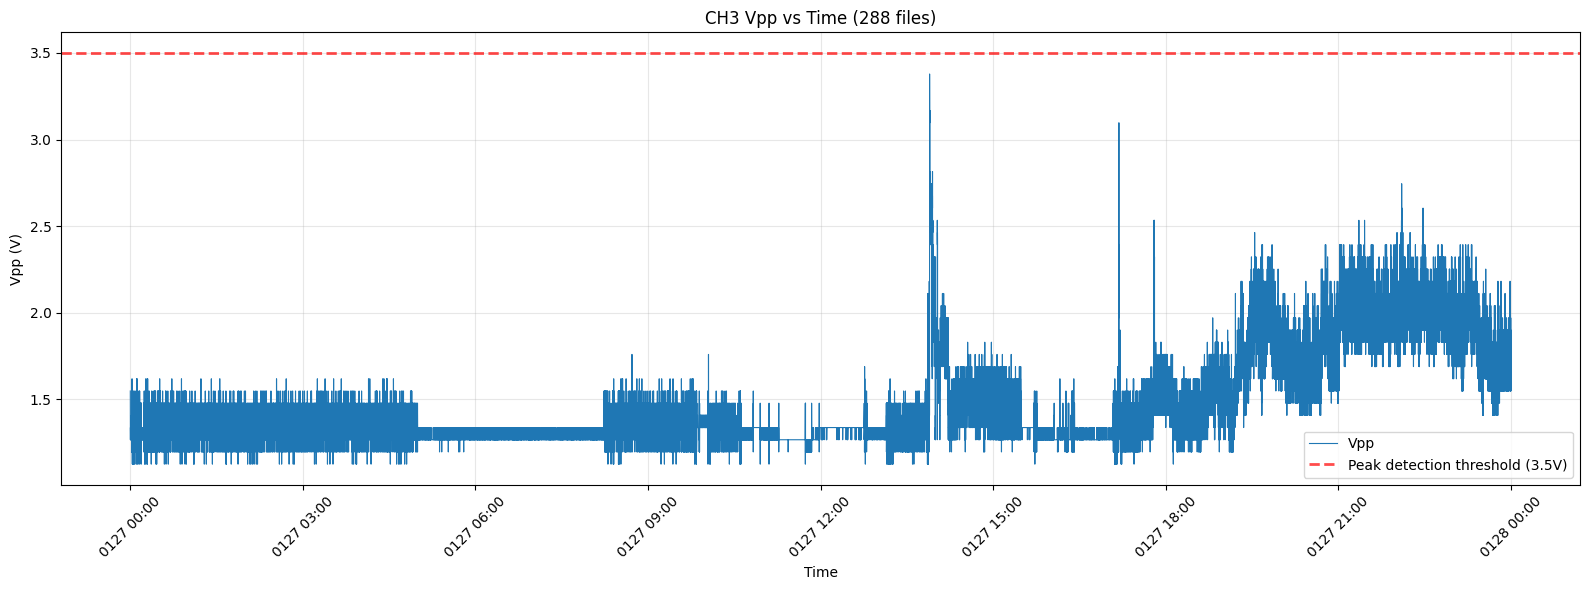


Found 0 peak(s) with Vpp > 3.5 V
No peaks found!

Batch processing complete!
Data saved to: /Users/xylu/Desktop/Data/acoustic_vpp/0014


In [ ]:
# Batch process one single date
import glob
import pandas as pd

# Parameters (CHANGE)
video_folder = "/Volumes/D06V1/D06V1/OSC_Videos/2026ab/20260224/"
# video_folder = "/Volumes/D06V1/D06V1/OSC_Videos/2026ab/20260127/RecData/0014/"

# max_files = 3  # Set to None to process all files
max_files = None # Uncomment to process all files
peak_threshold = 3.5  # V, for peak detection in Vpp signal

# Create output folder based on video folder name
folder_name = os.path.basename(video_folder.rstrip('/'))
output_folder = f"/Users/xylu/Desktop/Data/acoustic_vpp/{folder_name}" # Change this to your desired output path
os.makedirs(output_folder, exist_ok=True)

# Parameters (DO NOT CHANGE)
grid_height_px = 3.95/5.56*400/10 #for one grid corresponding to 2 V
v_div = 2.0
fps = 20.0

# Get folder from test_file
print(f"Processing .mkv files in: {video_folder}")
print("="*60)

# Find all .mkv files
mkv_files = sorted(glob.glob(os.path.join(video_folder, "*.mkv")))
print(f"Found {len(mkv_files)} total video file(s)")

# Process files (set to None to process all files)
if max_files is None:
    mkv_files_to_process = mkv_files
    print(f"Processing all {len(mkv_files_to_process)} file(s)")
else:
    mkv_files_to_process = mkv_files[:max_files]
    print(f"Processing {len(mkv_files_to_process)} file(s) (limited by max_files={max_files})")
print("="*60)

# Container for combined data
all_time_datetime = []
all_vpp_data = []
file_info = []

for file_idx, file_path in enumerate(mkv_files_to_process):
    basename = os.path.basename(file_path)
    print(f"\n[{file_idx + 1}/{len(mkv_files_to_process)}] {basename}")
    
    # Extract start time
    start_dt = extract_datetime_from_filename(basename)
    if start_dt is None:
        print(f"  ⚠ Skipped: Could not extract datetime")
        continue
    
    # Compute Vpp series
    try:
        time_s, vpp_data = compute_vpp_series_for_file(
            file_path,
            v_div=v_div,
            fps=fps,
            threshold=profile_threshold,
        )
        
        # Convert time to datetime
        time_datetime_data = np.array([start_dt + timedelta(seconds=t) for t in time_s])
        
        # Accumulate data
        all_time_datetime.extend(time_datetime_data)
        all_vpp_data.extend(vpp_data)
        
        # Create DataFrame for individual file
        df = pd.DataFrame({
            'time_datetime': time_datetime_data.astype(str),
            'time_seconds': time_s,
            'vpp_volts': vpp_data
        })
        
        # Save individual CSV
        csv_filename = basename.replace('.mkv', '_vpp.csv')
        csv_filepath = os.path.join(output_folder, csv_filename)
        df.to_csv(csv_filepath, index=False)
        
        vpp_min, vpp_max = np.nanmin(vpp_data), np.nanmax(vpp_data)
        print(f"  ✓ Vpp range: {vpp_min:.3f} - {vpp_max:.3f} V")
        file_info.append((basename, start_dt, vpp_min, vpp_max))
        
    except Exception as e:
        print(f"  ✗ Error: {str(e)}")

# Convert to arrays
all_time_datetime = np.array(all_time_datetime)
all_vpp_data = np.array(all_vpp_data)

print("\n" + "="*60)
print(f"COMBINED DATA: {len(all_vpp_data)} samples")
print(f"Vpp range: {np.nanmin(all_vpp_data):.3f} - {np.nanmax(all_vpp_data):.3f} V")
print(f"Time span: {all_time_datetime[0]} to {all_time_datetime[-1]}")
print("="*60)

# Plot combined Vpp vs time
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(all_time_datetime, all_vpp_data, linewidth=0.8, label='Vpp')
ax.axhline(y=peak_threshold, color='r', linestyle='--', linewidth=2, alpha=0.7, label=f'Peak detection threshold ({peak_threshold}V)')
ax.set_title(f"CH3 Vpp vs Time ({len(mkv_files_to_process)} files)")
ax.set_xlabel("Time")
ax.set_ylabel("Vpp (V)")
ax.legend()
ax.grid(True, alpha=0.3)

# Format x-axis as MMDD HH:MM
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m%d %H:%M'))
plt.xticks(rotation=45)
plt.tight_layout()
# plt.savefig(os.path.join(output_folder, "00_combined_vpp_plot.png"), dpi=100, bbox_inches='tight')
plt.show()

# Find peaks across combined dataset
vpp_peaks, peak_properties = find_peaks(all_vpp_data, height=peak_threshold, distance=20)
print(f"\nFound {len(vpp_peaks)} peak(s) with Vpp > {peak_threshold} V")
print("="*60)

if len(vpp_peaks) == 0:
    print("No peaks found!")
else:
    # Peak summary
    print("\n" + "="*60)
    print("PEAK SUMMARY")
    print("="*60)
    for peak_idx, sample_idx in enumerate(vpp_peaks):
        peak_time = all_time_datetime[sample_idx]
        vpp_val = all_vpp_data[sample_idx]
        print(f"Peak {peak_idx + 1}: {peak_time.strftime('%Y-%m-%d %H:%M:%S')} → Vpp = {vpp_val:.4f} V")

print("\nBatch processing complete!")
print(f"Data saved to: {output_folder}")

Saving peak summary and figure...


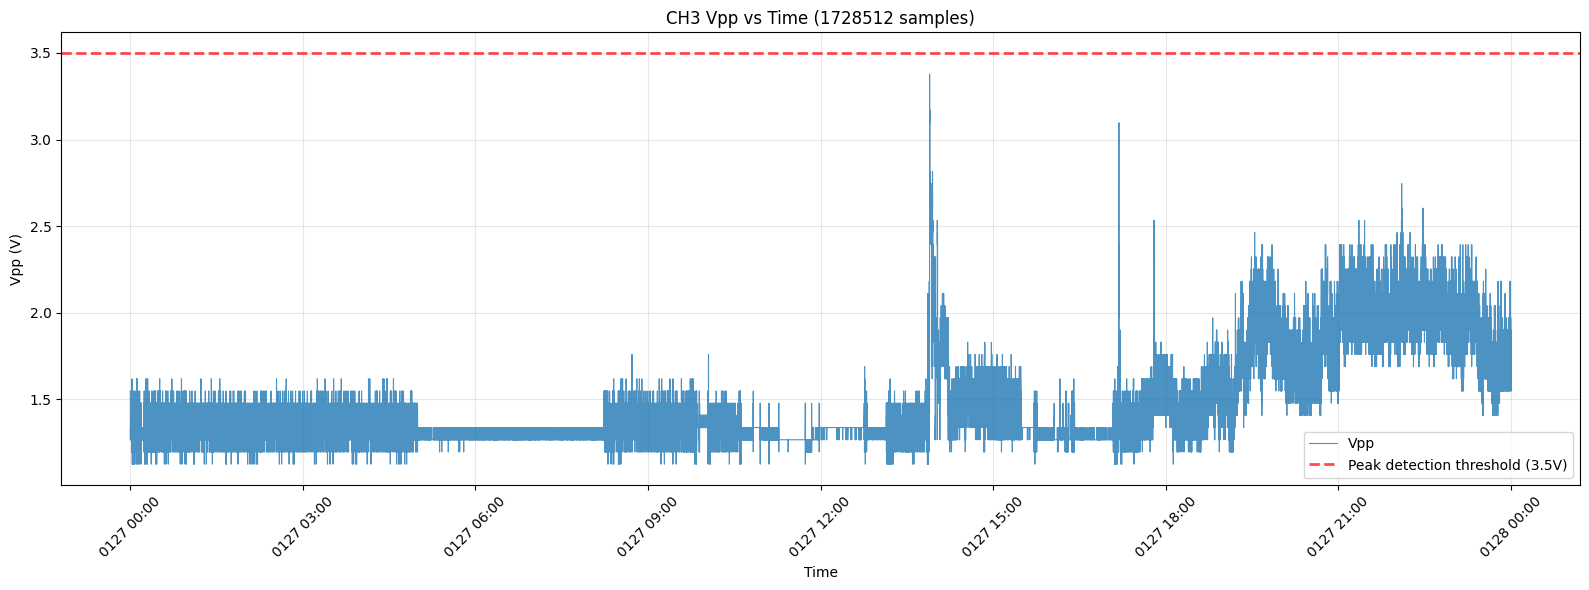

✓ Peak summary plot saved to: /Users/xylu/Desktop/Data/acoustic_vpp/summary/0014_peak_summary_plot.png
No peaks found!

Save complete!
Summary folder: /Users/xylu/Desktop/Data/acoustic_vpp/summary


In [17]:
# Save peak summary and figure (without rerunning batch processing)
# Uses the peak_data_list and vpp_peaks computed from the previous cell

print("Saving peak summary and figure...")
print("="*60)

# Get folder name for output filenames
folder_name = os.path.basename(output_folder.rstrip('/'))

# Create summary folder
summary_folder = os.path.abspath(os.path.join(output_folder, '../summary/'))
os.makedirs(summary_folder, exist_ok=True)

# Create summary figure (ALWAYS save PNG)
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(all_time_datetime, all_vpp_data, linewidth=0.8, label='Vpp', alpha=0.8)
ax.axhline(y=peak_threshold, color='r', linestyle='--', linewidth=2, alpha=0.7, label=f'Peak detection threshold ({peak_threshold}V)')
ax.set_title(f"CH3 Vpp vs Time ({len(all_vpp_data)} samples)")
ax.set_xlabel("Time")
ax.set_ylabel("Vpp (V)")
ax.legend()
ax.grid(True, alpha=0.3)

# Format x-axis as MMDD HH:MM
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m%d %H:%M'))
plt.xticks(rotation=45)
plt.tight_layout()
plot_path = os.path.join(summary_folder, f"{folder_name}_peak_summary_plot.png")
plt.savefig(plot_path, dpi=100, bbox_inches='tight')
plt.show()
print(f"✓ Peak summary plot saved to: {plot_path}")

# Save peak data CSV only if peaks found
if len(vpp_peaks) == 0:
    print("No peaks found!")
else:
    # Prepare peak data for saving
    peak_data_list = []
    for peak_idx, sample_idx in enumerate(vpp_peaks):
        peak_time = all_time_datetime[sample_idx]
        vpp_val = all_vpp_data[sample_idx]
        
        peak_data_list.append({
            'peak_number': peak_idx + 1,
            'frame_sample_idx': int(sample_idx),
            'time_datetime': peak_time.strftime('%Y-%m-%d %H:%M:%S.%f')[:-3],
            'vpp_volts': float(vpp_val)
        })
    
    # Save peak list to CSV
    peak_df = pd.DataFrame(peak_data_list)
    peak_csv_path = os.path.join(summary_folder, f"{folder_name}_peak_summary.csv")
    peak_df.to_csv(peak_csv_path, index=False)
    print(f"✓ Peak summary saved to: {peak_csv_path}")
    print(f"  Total peaks: {len(peak_data_list)}")

print("\nSave complete!")
print(f"Summary folder: {summary_folder}")